In [16]:
import networkx as nx
import matplotlib.pyplot as plt

graph = {
    "A": {
        "type": "OR",
        "children": [
            ("B", 2),
            ("C", 4)
        ]
    },

    "B": {
        "type": "OR",
        "children": [
            ("DE", 0),
            ("FG", 0)
        ]
    },

    "C": {
        "type": "OR",
        "children": [
            ("HI", 0),
            ("JK", 0)
        ]
    },

    "DE": {
        "type": "AND",
        "children": [
            ("D", 0),
            ("E", 0)
        ]
    },

    "FG": {
        "type": "AND",
        "children": [
            ("F", 0),
            ("G", 0)
        ]
    },

    "HI": {
        "type": "AND",
        "children": [
            ("H", 0),
            ("I", 0)
        ]
    },

    "JK": {
        "type": "AND",
        "children": [
            ("J", 0),
            ("K", 0)
        ]
    },

    "D": {"type": "GOAL", "cost": 3},
    "E": {"type": "GOAL", "cost": 2},
    "F": {"type": "GOAL", "cost": 1},
    "G": {"type": "GOAL", "cost": 5},
    "H": {"type": "GOAL", "cost": 2},
    "I": {"type": "GOAL", "cost": 2},
    "J": {"type": "GOAL", "cost": 1},
    "K": {"type": "GOAL", "cost": 1}
}


def ao_star(node):

    node_type = graph[node]["type"]

    # Goal node
    if node_type == "GOAL":
        return graph[node]["cost"], []

    # AND node
    if node_type == "AND":

        total_cost = 0
        solution_edges = []

        for child, edge_cost in graph[node]["children"]:

            child_cost, child_edges = ao_star(child)

            total_cost += edge_cost + child_cost

            solution_edges.append((node, child))
            solution_edges.extend(child_edges)

        return total_cost, solution_edges

    # OR node
    if node_type == "OR":

        alternatives = []

        for child, edge_cost in graph[node]["children"]:

            child_cost, child_edges = ao_star(child)

            total_cost = edge_cost + child_cost

            alternatives.append(
                (total_cost, child, child_edges)
            )

        best_cost, best_child, best_edges = min(
            alternatives,
            key=lambda x: x[0]
        )

        solution_edges = [
            (node, best_child)
        ]

        solution_edges.extend(best_edges)

        return best_cost, solution_edges


optimal_cost, optimal_edges = ao_star("A")

print("=" * 60)
print("AO* ALGORITHM RESULT")
print("=" * 60)

print("Optimal Cost:", optimal_cost)

print("\nOptimal Solution Subgraph:")

for source, target in optimal_edges:
    print(source, "->", target)

print("\nFinal Solution:")
print("A -> C -> (J AND K)")

print("\nTotal Cost = 6")

AO* ALGORITHM RESULT
Optimal Cost: 6

Optimal Solution Subgraph:
A -> C
C -> JK
JK -> J
JK -> K

Final Solution:
A -> C -> (J AND K)

Total Cost = 6


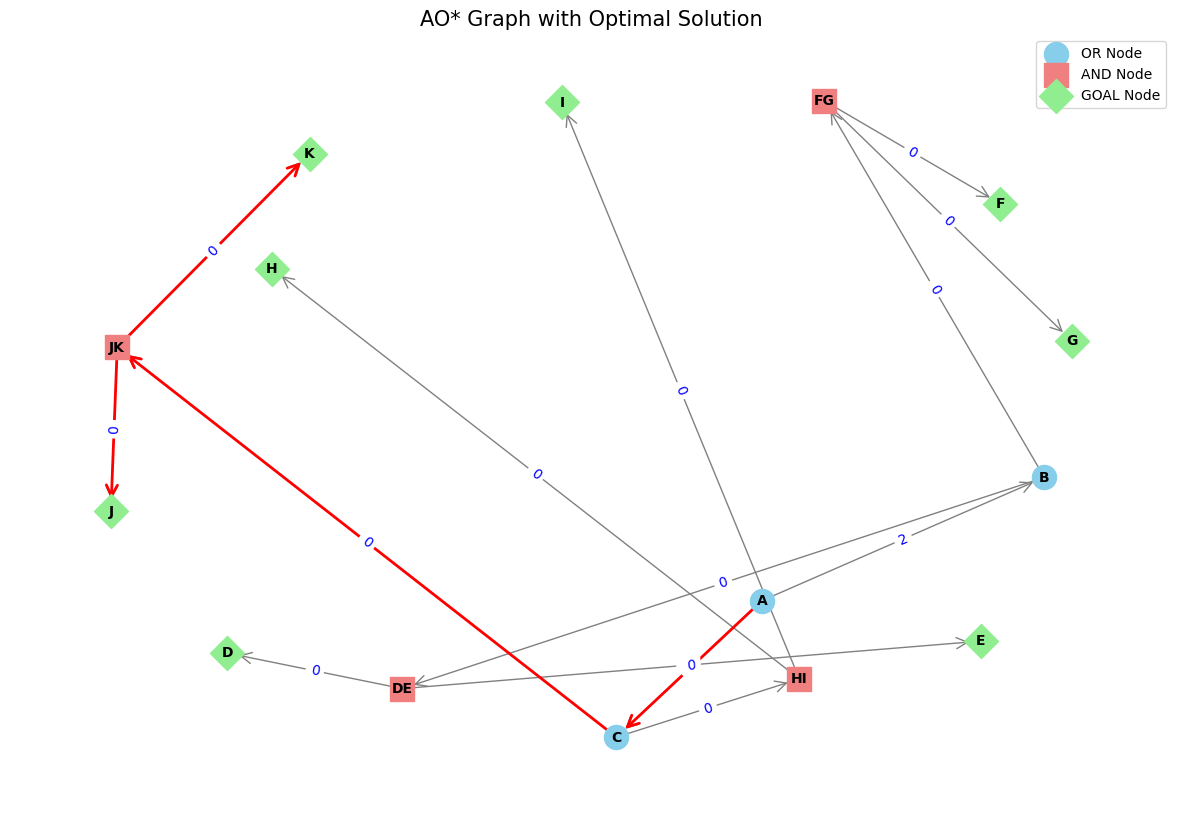

In [19]:
import networkx as nx
import matplotlib.pyplot as plt

def draw_ao_graph(graph, optimal_edges):
    G = nx.DiGraph()

    or_nodes = []
    and_nodes = []
    goal_nodes = []

    # Add nodes and edges to the graph
    for node, data in graph.items():
        node_type = data['type']
        if node_type == 'OR':
            or_nodes.append(node)
        elif node_type == 'AND':
            and_nodes.append(node)
        elif node_type == 'GOAL':
            goal_nodes.append(node)

        if 'children' in data:
            for child, edge_cost in data['children']:
                G.add_edge(node, child, weight=edge_cost)

    pos = nx.spring_layout(G, k=0.8, iterations=50)

    plt.figure(figsize=(15, 10))

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, nodelist=or_nodes, node_color='skyblue', node_shape='o', label='OR Node')
    nx.draw_networkx_nodes(G, pos, nodelist=and_nodes, node_color='lightcoral', node_shape='s', label='AND Node')
    nx.draw_networkx_nodes(G, pos, nodelist=goal_nodes, node_color='lightgreen', node_shape='D', label='GOAL Node')

    # Draw all edges
    nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, arrowstyle='->', arrowsize=20)

    # Draw optimal path edges in a different color
    nx.draw_networkx_edges(G, pos, edgelist=optimal_edges, edge_color='red', width=2, arrows=True, arrowstyle='->', arrowsize=20, label='Optimal Path')

    # Draw node labels
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

    # Draw edge labels (costs)
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='blue')

    plt.title('AO* Graph with Optimal Solution', size=15)
    plt.legend()
    plt.axis('off')
    plt.show()

# Draw the graph with the optimal path
draw_ao_graph(graph, optimal_edges)

In [18]:
def ao_star(node):

    node_type = graph[node]["type"]

    if node_type == "GOAL":
        return graph[node]["cost"], []

    if node_type == "AND":

        total_cost = 0
        solution_edges = []

        for child, edge_cost in graph[node]["children"]:

            child_cost, child_edges = ao_star(child)

            total_cost += edge_cost + child_cost

            solution_edges.append((node, child))
            solution_edges.extend(child_edges)

        return total_cost, solution_edges

    if node_type == "OR":

        alternatives = []

        for child, edge_cost in graph[node]["children"]:

            child_cost, child_edges = ao_star(child)

            total_cost = edge_cost + child_cost

            alternatives.append(
                (total_cost, child, child_edges)
            )

        best_cost, best_child, best_edges = min(
            alternatives,
            key=lambda x: x[0]
        )

        solution_edges = [(node, best_child)]
        solution_edges.extend(best_edges)

        return best_cost, solution_edges